# **Analisi delle precipitazioni estreme  nel Veneto (1945-2022)**

L'obiettivo di questo esercizio è quello di:
1) individuare i valori estremi delle precipitazioni del Veneto, dal 1945 al 2022. Attraverso il modello Block Maxima.
2) Stimare i periodi di ritorno di queste misurazioni estreme.

Si utilizzeranno per questi scopi le funzioni della libreria apposita, pyextreme.

I dati sono stati ricavati dalle stazioni meteorologiche messe a disposizione dall' ISPRA.

In [ ]:
# Installiamo la libreria pyextreme e importiamo la classe EVA per l'esecuzione del metodo Block Maxima,  e il metodo get_return_periods per stimare i tempi di ritorno.

!pip install pyextremes

import pandas as pd
from pyextremes import EVA
from pyextremes import get_return_periods


In [ ]:
# Si apre il dataset e lo si salva nella variabile df, inoltre ne stampiamo le informazione generali.
# Il dataframe è composto da 201025 records e tre colonne: la data, la rete anagrafica e le precipitazioni cumulate in millimetri.

df = pd.read_csv("Veneto.csv", index_col=2,
    parse_dates=True,)

print(type(df))

print(df.shape)

print(df.head())



/tmp/ipython-input-1945988664.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("Veneto.csv", index_col=2,


<class 'pandas.core.frame.DataFrame'>
(201025, 3)
                         rete         anagrafica  Precipitazioni cumulate
data                                                                     
1955-01-01  REGIONI - ex SIMN  Auronzo di Cadore                    0.000
1955-01-02  REGIONI - ex SIMN  Auronzo di Cadore                    0.000
1955-01-03  REGIONI - ex SIMN  Auronzo di Cadore                    0.588
1955-01-04  REGIONI - ex SIMN  Auronzo di Cadore                    0.420
1955-01-05  REGIONI - ex SIMN  Auronzo di Cadore                    0.000


In [ ]:
# Eliminiamo la variabile "rete anagrafica" e associamo ad ogni data il valore pluviometrico massimo corrispondente.
# In questo modo creiamo una serie e gli assegniamo la denominazione "data".

data = df.groupby(["data"]).max().drop(["rete","anagrafica"], axis=1).squeeze()

print(data)

data
1951-01-01     0.0
1951-01-02     6.4
1951-01-03    63.0
1951-01-04     5.0
1951-01-05     0.0
              ... 
2022-12-27     0.0
2022-12-28     0.0
2022-12-29     3.8
2022-12-30     5.1
2022-12-31     0.3
Name: Precipitazioni cumulate, Length: 26298, dtype: float64


(<Figure size 768x480 with 1 Axes>,
 <Axes: xlabel='data', ylabel='Precipitazioni cumulate'>)

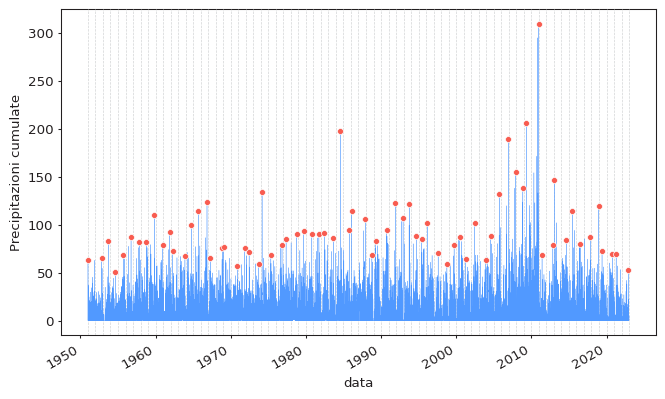

In [ ]:
# Associamo la classe EVA contenente i tools per l'analisi dei nostri dati alla serie (data) ricavata dal nostro dataframe.
# Creiamo il nostro modello Block Maxima utilizzando la funzione get_extreme.
# Suddividiamo la nostra serie in blocchi di un anno ciascuno.
# Ed elaboriamo i plot via plot_extremes. Sono chiaramente visibili i valori estremi.
# Il massimo picco, 309.2 mm, è stato raggiunto nel 2010.

model = EVA(data)

model.get_extremes(method="BM", block_size="365.2425D", errors="coerce")

model.plot_extremes()

In [ ]:
# La seguente tabella mostra i valori estremi in ordine decrescente e reinforza ciò che abbiamo potuto apprezzare nel grafico; questa volta indicandoci la data esatta.

model.extremes.sort_values(ascending=False)

,Precipitazioni cumulate
data,
2010-12-24,309.200
2009-04-28,205.600
1984-08-09,198.000
2006-12-09,189.200
2007-11-24,154.800
...,...
1973-09-25,59.214
1998-10-07,58.800
1970-11-14,56.758


In [ ]:
# Si stimano i valori dei parametri in base alla distribuzione dei nostri outliers.

model.fit_model()

In [ ]:
# Ricaviamo una tabella che ci fornisce la stima dei valori di ritorno fra 1, 2, 5, 10 anni.
# L'intervallo di confidenza, alpha, è del 95%.
# Prendendo in considerazione l'orizzonte dei 10 anni, abbiamo una probabilità del 10% che tale valore estremo, 137.5 mm, si verifichi in un determinato anno.

summary = model.get_summary(
    return_period=[1, 2, 5, 10],
    alpha=0.95, n_samples=1000,)

print(summary)

               return value    lower ci    upper ci
return period                                      
1.0               -0.649843 -242.698150   39.660588
2.0               85.284518   78.686334   91.545645
5.0              113.758065  101.427690  127.076065
10.0             137.625996  117.487795  162.090381


In [ ]:
# Il comando fornisce i dati sul nostro modello. Il parametro c (ξ) di valore -0.252 ci informa che rientra nel campo della distribuzione di Weibull.

model.distribution

             pyextremes distribution              
--------------------------------------------------
name: genextreme                                  
free parameters: c, loc, scale                    
fixed parameters: all parameters are free         
MLE parameters: c=-0.252, loc=77.689, scale=19.780
--------------------------------------------------

(<Figure size 768x768 with 4 Axes>,
 (<Axes: title={'center': 'Return value plot'}, xlabel='Return period', ylabel='Precipitazioni cumulate'>,
  <Axes: title={'center': 'Probability density plot'}, xlabel='Precipitazioni cumulate', ylabel='Probability density'>,
  <Axes: title={'center': 'Q-Q plot'}, xlabel='Theoretical', ylabel='Observed'>,
  <Axes: title={'center': 'P-P plot'}, xlabel='Theoretical', ylabel='Observed'>))

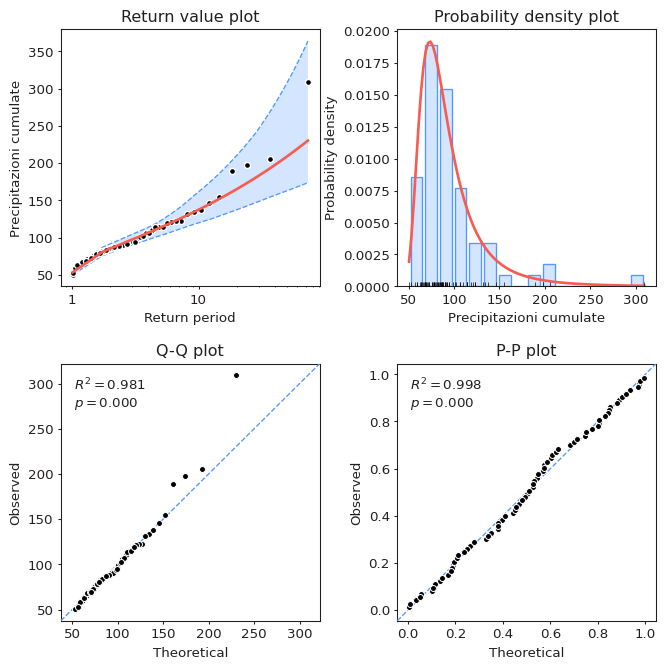

In [ ]:
# Attraverso la funzione "plot_diagnostic" elaboriamo quattro plot. Il primo, return value plot, rappresenta la stima dei valori estremi nel corso del tempo, Il plot rappresenta con esattezza le informazioni riportate nella tabella precedente.
# Nella Probability density plot sono rappresentati la distribuzione dei valori massimi delle precipitazioni paragonati alla funzione di probabilità del nostro modello. Sono notevoli i picchi presso la coda della funziona (200- 300 mm), i quali naturalmente presentano una bassa probabilità.
# Il Q-Q plot e il P-P plot  comparano rispettivamente i quantili della distribuzione della nostra serie con i quantili della funzione di distribuzione del nostro modello (Weibull), e la funzione cumulativa del nostro dataset con quella della funzione di riferimento.
# Il risultato è che il nostro modello spiega abbastanza bene la varianza dei nostri dati con un  R squared superiore al 95%.

model.plot_diagnostic(alpha=0.95)

In [ ]:
# Chiamo la funzione che mi restituisce i periodi di ritorno su base annuale attraverso il metodo Block Maxima.

return_periods = get_return_periods(
    ts=data,
    extremes=model.extremes,
    extremes_method="BM",
    extremes_type="high",
    block_size="365.2425D",
    return_period_size="365.2425D",
    plotting_position="weibull",
)
# ...E stampo il risultato in ordine discendente in base al periodo di ritorno.
# Secondo la stima del modello ci si dovrebbe aspettare una probabilità del 1.3% che si riscontri un superamento, o una ripetizione, del picco massimo di 309 mm in un dato anno.
# Ed in media occorrerebbero 73 anni affinché un fenomeno di tale intensità si ripresenti.

return_periods.sort_values("return period", ascending=False).head()

,Precipitazioni cumulate,exceedance probability,return period
data,,,
2010-12-24,309.2,0.013699,73.000000
2009-04-28,205.6,0.027397,36.500000
1984-08-09,198.0,0.041096,24.333333
2006-12-09,189.2,0.054795,18.250000
2007-11-24,154.8,0.068493,14.600000
